# Current-Voltage Curves

This example demonstrates how to measure current-voltage curves using the [zahner_link](https://doc.zahner.de/im7/apis/zahner_link/python/) library with your IM7 potentiostat.

These measurements are known by various names depending on the specific technique used. In the [zahner_link](https://doc.zahner.de/im7/apis/zahner_link/python/) API, all these techniques are implemented as ramps with different parameters as the [RampJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.RampJob). Common names include:
* Current-Voltage Curves (I-V/IE)
* Galvanostatic Ramp
* Potentiostatic Ramp
* Linear Sweep Voltammetry (LSV)
* Linear Sweep Galvanostatic
* Staircase Voltammetry
* Staircase Galvanostatic

For stairs with stability criteria per step, there is the [SteadyStairsJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.SteadyStairsJob), which can be used to map the following methods, among others:

* Steady State Staircase Voltammetry
* Steady State Staircase Galvanostatic

In this notebook, you'll learn how to:
* Connect to an IM7 electrochemical workstation
* Run a galvanostatic linear ramp using [RampJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.RampJob)
* Run a Steady State Staircase Voltammetry [SteadyStairsJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.SteadyStairsJob) with current stop criteria
* Perform a potentiostatic staircase ramp (Cyclic Voltammetry) using [CvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.CvJob) with current limits
* Process staircase data to extract endpoint values for clearer analysis
* Create different plots of your data (time-based, voltage vs. current, and logarithmic plots)

For file saving and other basic operations, please see our other example notebooks.

Let's start by defining two helper functions that will make plotting our measurement data easier.

In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
from typing import Optional, List
import numpy as np
import zahner_link as zl


def plot_dataset_tiu(dataset: zl.DcDataset):
    """Plot voltage and current vs time from a dataset.

    This function creates a dual-axis plot showing voltage and current
    measurements over time from a DC dataset.
    """
    time = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    (line1,) = ax1.plot(time, voltage, color="blue", label="Voltage", marker="x")
    (line2,) = ax2.plot(time, current, color="red", label="Current", marker="x")
    ax1.legend(handles=[line1, line2])

    ax1.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Voltage")
    ax2.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax2.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Current")

    fig.set_size_inches(18, 10)
    plt.show()
    return


def plot_dataset_ui(dataset: zl.DcDataset):
    """Plot current vs voltage from a dataset.

    This function creates a standard current-voltage plot (I-V curve)
    from a DC dataset.
    """
    time = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    fig, ax1 = plt.subplots()
    (line1,) = ax1.plot(voltage, current, color="blue", marker="x")

    ax1.xaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
    ax1.set_xlabel("Voltage")
    ax1.set_ylabel("Current")

    fig.set_size_inches(18, 10)
    plt.show()
    return

## Connecting to the IM7 and Setting Up

Now we'll connect to the IM7 potentiostat and set it up for our first measurement. We'll start in galvanostatic mode (current control) for our first current-voltage curve.

In [ ]:
link = zl.ZahnerLinkExc("10.10.253.154", "1994")
error: zl.ErrorObject = link.connect()

if not error:
    print("connected successfully")
else:
    print(f"failed to connect, status: {error.get_error_code_enum()}, message: {error.get_message_formatted()}")

switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.GALVANOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")

link.do_job(switch_on_job)

connected successfully


## Galvanostatic Linear Sweep

With the potentiostat in galvanostatic mode, we'll run a linear current ramp from 0 A to 1 A using the [RampJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.RampJob).

We're configuring the ramp with these parameters:
- `start_value` and `end_value`: Define our ramp range (0 A to 1 A)
- `scan_rate`: How fast to sweep (0.1 A/s)
- `step_height`: Set to 0, instructing the IM7 to use the smallest possible step size with its 32-bit DAC
- `output_data_rate`: How many data points per second to record (10 Hz)

After the measurement completes, we'll plot the results in two ways: time vs. voltage/current and voltage vs. current.

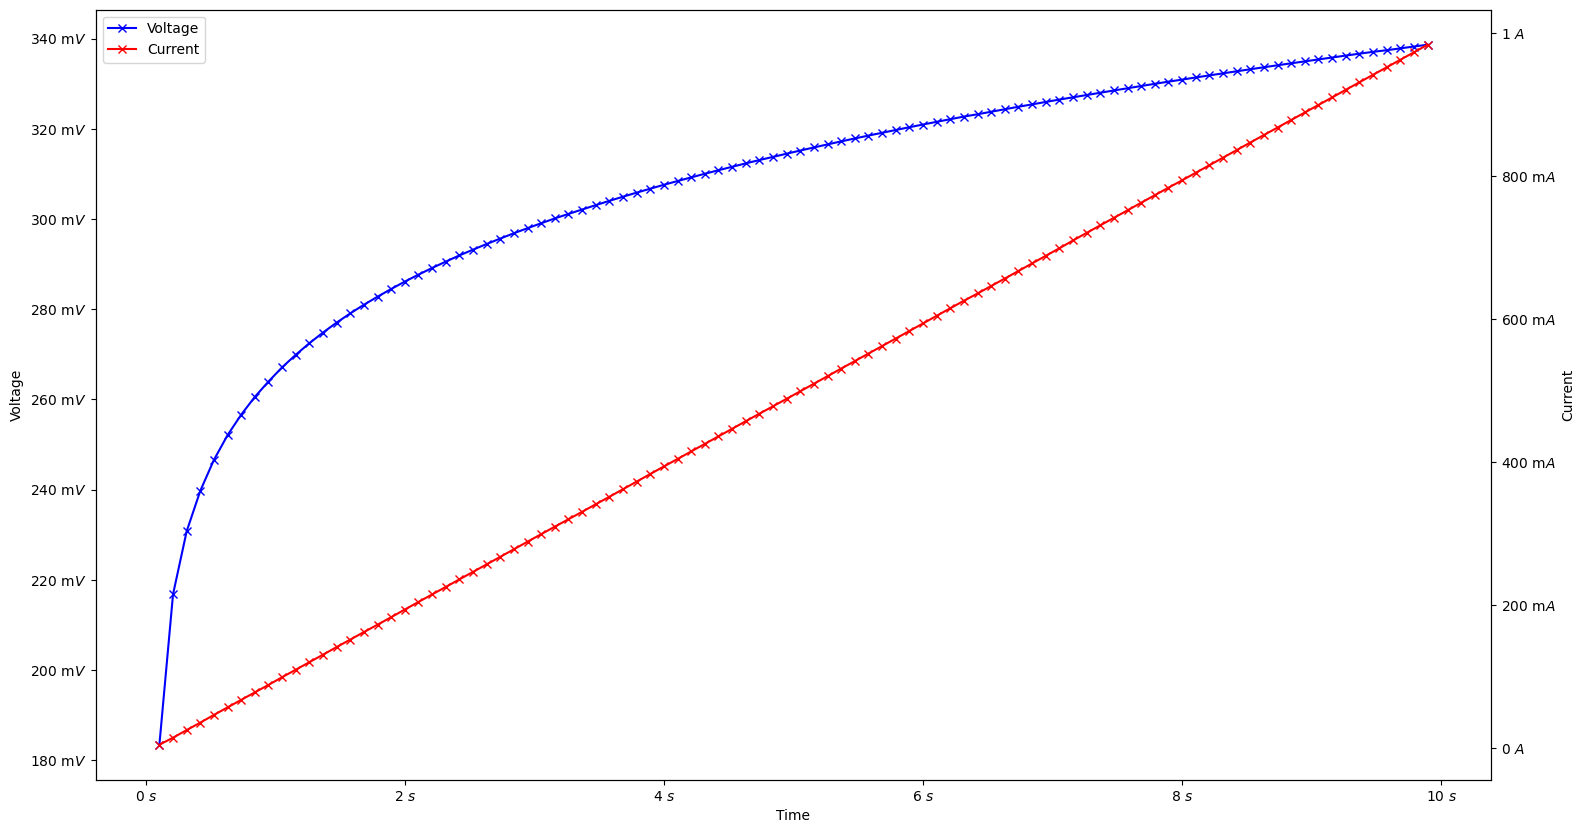

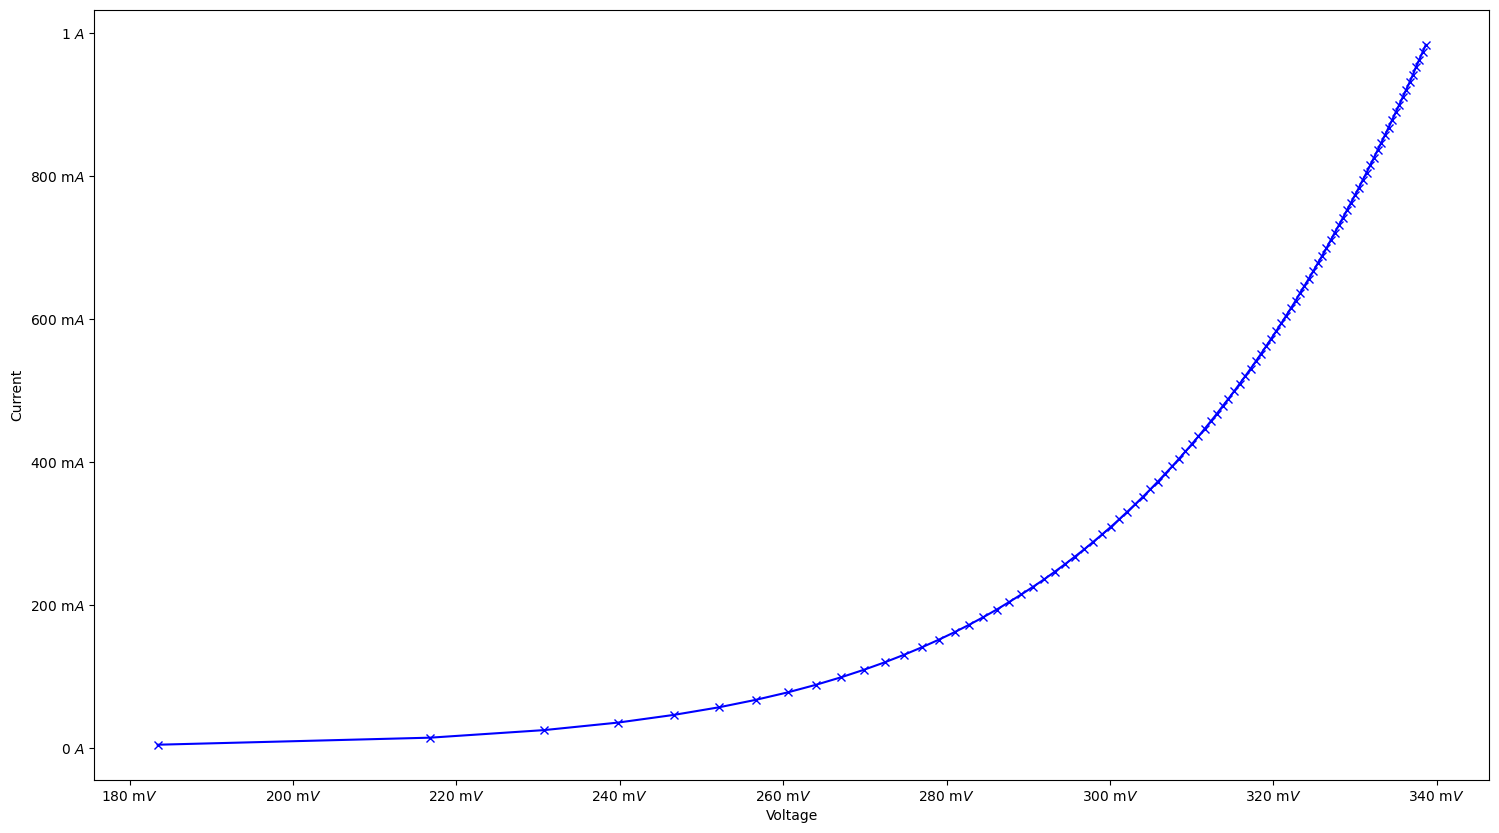

In [ ]:
linear_ramp_job = zl.meas.RampJob(
    start_value=0,  # Start at 0 A
    end_value=1,  # End at 1 A
    scan_rate=0.1,  # 0.1 A per second
    step_height=0,  # Let IM7 choose smallest step size
    output_data_rate=10,  # 10 points per second
    autorange=True,  # Auto-select measurement ranges
    current_range=0.1,  # Only used if autorange=False
)
link.do_job(linear_ramp_job)
linear_ramp_data = link.get_job_result_data(linear_ramp_job)

plot_dataset_tiu(linear_ramp_data)
plot_dataset_ui(linear_ramp_data)

## Steady State Staircase

Instead of a linear sweep with constant scanning, it is also possible to take measurements at discrete values and apply a stability criterion before proceeding to the next value. For this job, we will also switch to potentiostatic mode (voltage control).

This allows measurements to be taken at different voltages until the current stabilizes. This is accomplished using the [SteadyStairsJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.SteadyStairsJob).

The staircase with stability criteria is combined with a [MinMaxLimitStopCondition](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#zahner_link.meas.stop.MinMaxLimitStopCondition) to stop the staircase if the absolute maximum current of 1 A is exceeded.

Stop conditions allow measurements to be terminated early, before their configured runtime, based on various criteria.
For example, a constant current polarization can be stopped once a specific voltage limit is reached.
Another example is an OCV scan that automatically stops when the open-circuit voltage has stabilized.

Various [stop conditions](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#stop-conditions) are available; the most important ones are:

* [MinMaxLimitStopCondition](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#zahner_link.meas.stop.MinMaxLimitStopCondition) - stops the measurement when a minimum or maximum value is reached.
* [StabilityToleranceLimitStopCondition](https://doc.zahner.de/im7/apis/zahner_link/python/pages/stopconditions.html#zahner_link.meas.stop.StabilityToleranceLimitStopCondition) - stops the measurement when a value has stabilized.

successfully stopped on stop condition, error code: ErrorCodeEnum.STOP_CONDITION_TRIGGERED, message: stop condition #0 triggered: current: 1.00294 < -1 or 1.00294 > 1


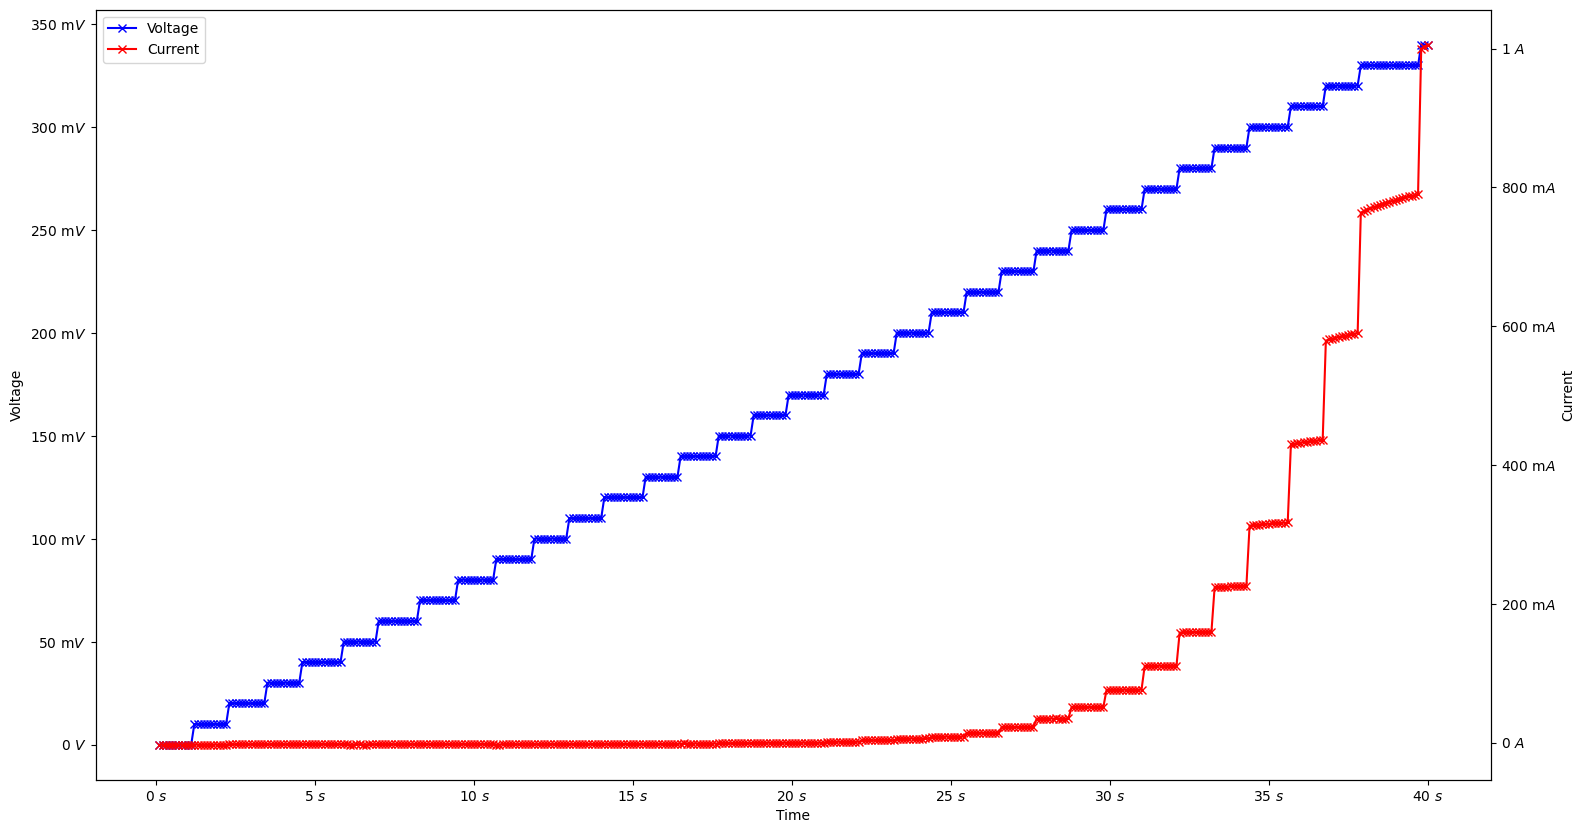

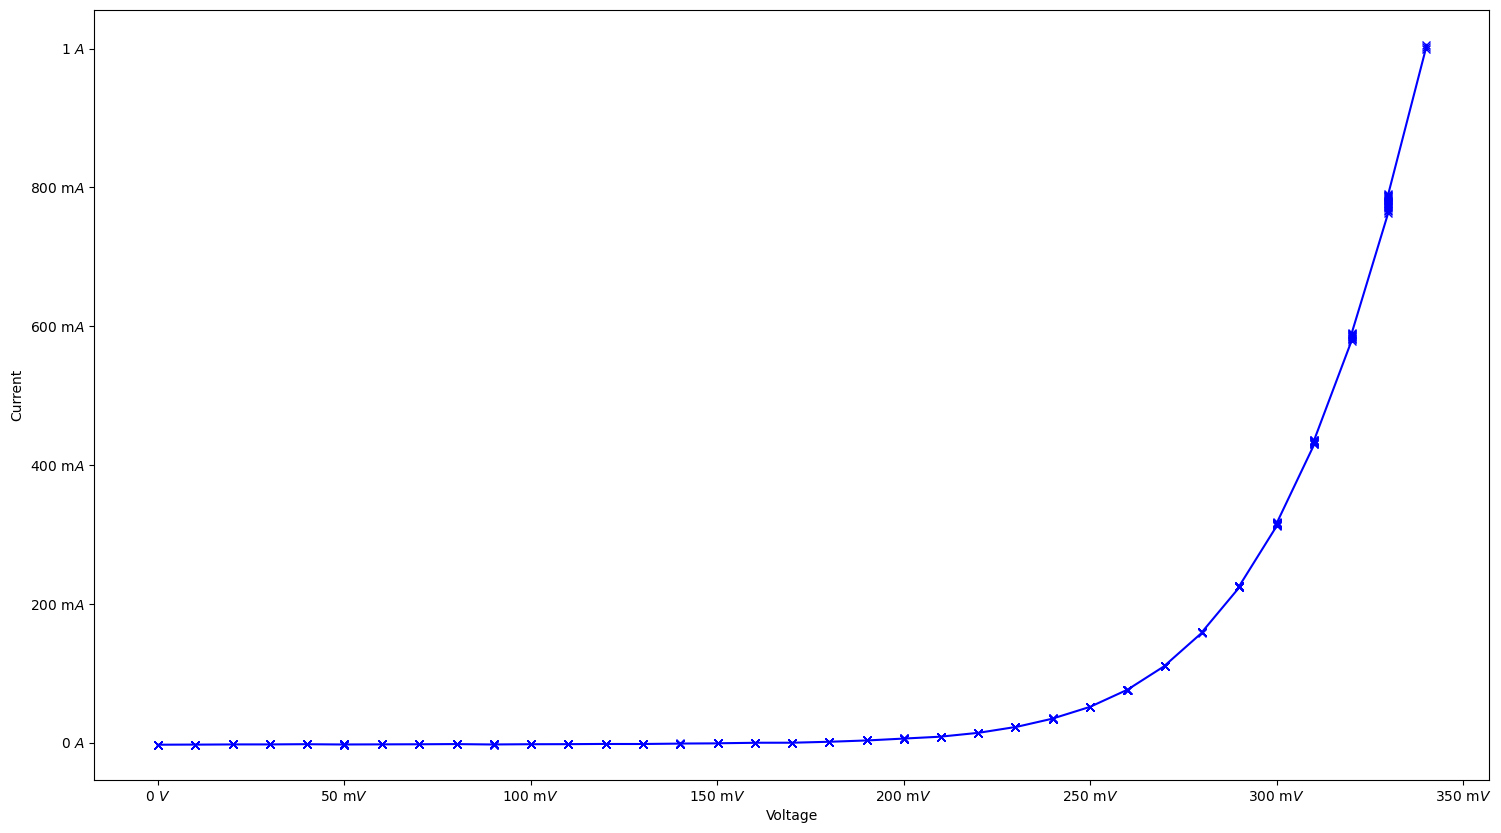

In [ ]:
link.do_job(switch_off_job)
switch_on_job.parameters.coupling = zl.PotentiostatCoupling.POTENTIOSTATIC
link.do_job(switch_on_job)


stop_conditions = [
    zl.meas.stop.MinMaxLimitStopCondition(
        for_dimension="current", minimum=-1, maximum=1
    )  # stop at a absolute maximum current of 1 A
]
steady_stairs_job = zl.meas.SteadyStairsJob(
    start_value=0,  # Start at 0 V
    end_value=1,  # End at 1 V
    step_time=2,  # maximum of 2 seconds
    step_height=0.01,  # 10 mV steps
    hold_time=1,  # at least 1 second
    stability_tolerance=0.01,  # 10 mA/s stability criterion
    output_data_rate=10,  # 10 points per second
    autorange=False,  # no autorange, use fixed ranges
    current_range=1,  # fixed current range of 1 A
    stop_conditions=stop_conditions,
)

try:
    link.do_job(steady_stairs_job)
except zl.ZahnerLinkException as e:
    error_object: zl.ErrorObject = e.error
    if error_object.get_error_code_enum() == zl.ErrorCodeEnum.STOP_CONDITION_TRIGGERED:
        print(f"successfully stopped on stop condition, error code: {error_object.get_error_code_enum()}, message: {error_object.get_message_formatted()}")

steady_stairs_data = link.get_job_result_data(steady_stairs_job)

plot_dataset_tiu(steady_stairs_data)
plot_dataset_ui(steady_stairs_data)

In the previous plot, which shows current and voltage as a function of time, the longer steps are clearly visible at higher currents.

It's also apparent that the staircase measurement is immediately terminated after a current greater than 1 A is measured.

The following code retrieves information about why the job was stopped, in this case due to the stop condition:

In [5]:
info = steady_stairs_job.get_last_job_info()
error = info.get_error()

if error and error.get_error_code_enum() == zl.ErrorCodeEnum.STOP_CONDITION_TRIGGERED:
    print(f"Error code: {error.get_error_code_enum()}")
    print(error.get_message_formatted())
    print(error.get_message_format_string())
    print(error.get_message_parameters())
    triggered_stop_condition = stop_conditions[error.get_message_parameters()[0]]
    print(f"Triggered stop condition: {triggered_stop_condition}")

Error code: ErrorCodeEnum.STOP_CONDITION_TRIGGERED
stop condition #0 triggered: current: 2.21279 < -1 or 2.21279 > 1
stop condition #{0} triggered: {1}
[0, 'current: 2.21279 < -1 or 2.21279 > 1']
Triggered stop condition: <zahner_link._zahner_link.meas.stop.MinMaxLimitStopCondition object at 0x0000023357682AB0>


## Potentiostatic Ramps

Now we'll use the [CvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.CvJob) to perform multiple ramps. Note that the [RampJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.RampJob) could also be used.

**Important Note:** The behavior of [CvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.CvJob) adapts to the potentiostat's operating mode:
- In potentiostatic mode: Parameters like `start_value` control voltage, and boundary parameters control current
- In galvanostatic mode: Parameters like `start_value` control current, and boundary parameters control voltage

For our staircase voltammetry, we'll use:
- `step_height`: 0.01 V to create discrete voltage steps
- `turn_limit_check`: Enabled to protect our sample by setting current limits
- `upper_turn_boundary` and `lower_turn_boundary`: +1 A and -1 A limits

This will perform a triangular voltage sweep from 0V → +0.5V → -0.5V → 0V, but will reverse direction earlier if current exceeds either limit.

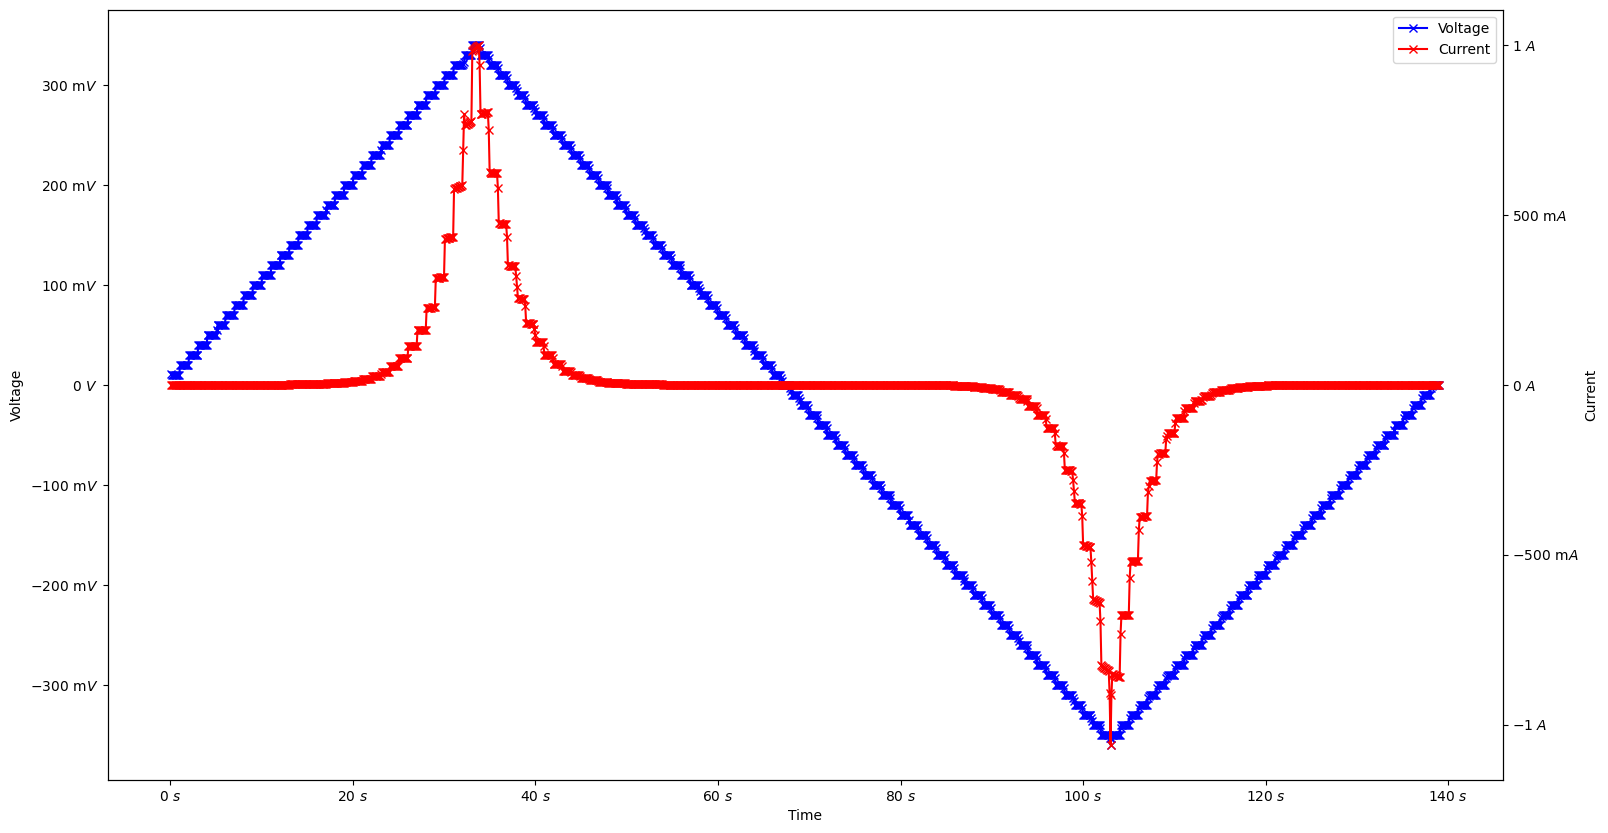

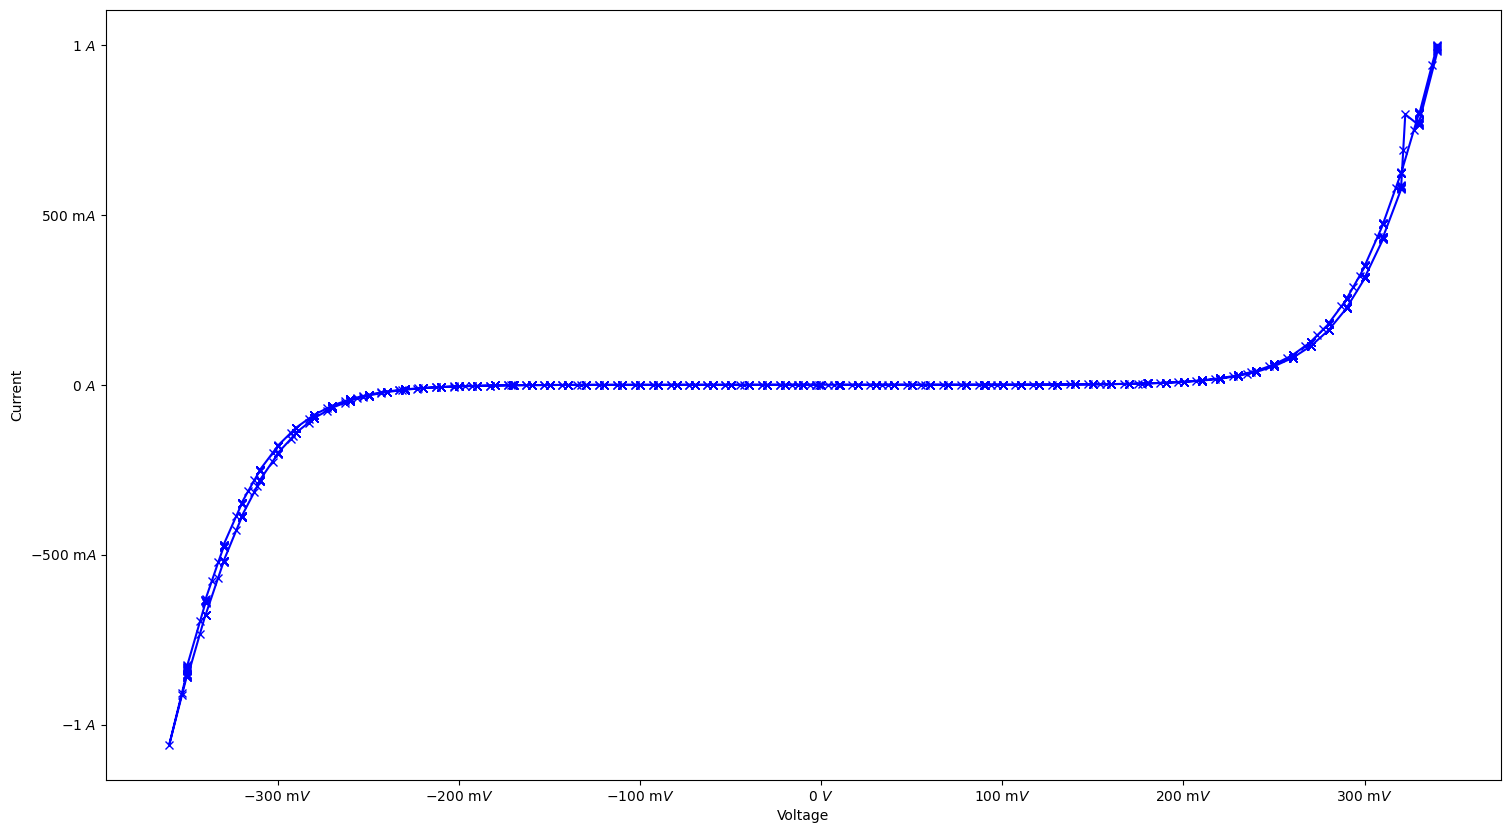

In [6]:
stairs_height = 0.01
stairs_ramp_job = zl.meas.CvJob(
    start_value=0,
    first_vertex=0.5,
    second_vertex=-0.5,
    end_value=0,
    scan_rate=0.01,
    output_data_rate=10,
    num_cycles=0.5,
    autorange=True,
    current_range=1,
    turn_limit_check=True,
    upper_turn_boundary=1,
    lower_turn_boundary=-1,
    step_height=stairs_height,
    ir_drop=0,
)
link.do_job(stairs_ramp_job)
stairs_ramp_data = link.get_job_result_data(stairs_ramp_job)

plot_dataset_tiu(stairs_ramp_data)
plot_dataset_ui(stairs_ramp_data)

## Switch Off and Disconnect

Now that we've completed our measurements, let's properly shut down by turning off the potentiostat and disconnecting from the IM7.

Note that disconnecting doesn't affect our measurement data - we can still access it from the job objects we created earlier.

In [7]:
link.do_job(switch_off_job)
link.disconnect()

## Advanced Data Processing for Staircase Measurements

Staircase ramps produce data with transient current spikes whenever the voltage changes. These transients can make it difficult to see the true steady-state relationship between voltage and current.

To get cleaner results, we'll extract only the current values measured at the end of each voltage step, when the transients have settled. This gives us a better representation of the steady-state response.

We'll define two helper functions:
1. `find_step_endpoints`: Identifies the last data point in each voltage step before the voltage changes
2. `get_step_values`: Extracts these specific endpoint values from our raw data arrays

In [8]:
stair_voltage = stairs_ramp_data.get_dc_track("voltage")
stair_current = stairs_ramp_data.get_dc_track("current")


def find_step_endpoints(
    data: List[float],
    step_height: float,
    min_value: Optional[float] = None,
    max_value: Optional[float] = None,
) -> np.array:
    """
    Find the indices where each step ends in a staircase signal.

    This function analyzes a staircase signal and identifies the last
    data point of each step before the signal changes to the next level.

    :param data: The signal to analyze (e.g., voltage measurements)
    :param step_height: The height of each step (e.g., 0.01V)
    :param min_value: Optional minimum value (auto-detected if None)
    :param max_value: Optional maximum value (auto-detected if None)
    :return: Array of indices marking the end of each step
    """
    signal = np.array(data)

    if min_value is None:
        min_value = np.min(signal)
    if max_value is None:
        max_value = np.max(signal)

    lowest_bin = np.floor(min_value / step_height) * step_height
    highest_bin = np.ceil(max_value / step_height) * step_height

    bin_centers = np.arange(lowest_bin, highest_bin + step_height, step_height)
    bin_edges = np.concatenate(
        [bin_centers - step_height / 4, [bin_centers[-1] + step_height / 4]]
    )
    bin_edges.sort()

    bin_indices = np.digitize(signal, bin_edges)

    endpoints = []
    current_bin = bin_indices[0]

    for i in range(1, len(signal)):
        if bin_indices[i] != current_bin:
            endpoints.append(i - 1)
            current_bin = bin_indices[i]
        elif i < len(signal) - 1:
            next_bin = bin_indices[i + 1]
            if next_bin != current_bin:
                endpoints.append(i)

    if not endpoints or endpoints[-1] != len(signal) - 1:
        endpoints.append(len(signal) - 1)

    return np.array(endpoints)


def get_step_values(data: List[float], indexes: List[int]) -> np.array:
    """
    Extract values at specific indices from a data array.

    :param data: The source data array
    :param indexes: The indices to extract
    :return: Array containing only the values at the specified indices
    """
    return np.array([data[i] for i in indexes])

Now let's use these functions to process our staircase measurement data. We'll find the endpoint of each voltage step and extract the corresponding voltage and current values.

In [9]:
endpoints_on_steps = find_step_endpoints(stair_voltage, stairs_height)

stair_voltage_end_values = get_step_values(stair_voltage, endpoints_on_steps)
stair_current_end_values = get_step_values(stair_current, endpoints_on_steps)

## Creating a Logarithmic Current-Voltage Plot

Finally, let's visualize our processed data using a logarithmic plot of current vs. voltage. The logarithmic scale for current helps reveal both small and large current values in the same plot, which is especially useful for semiconductor devices and electrochemical systems where current can vary by many orders of magnitude.

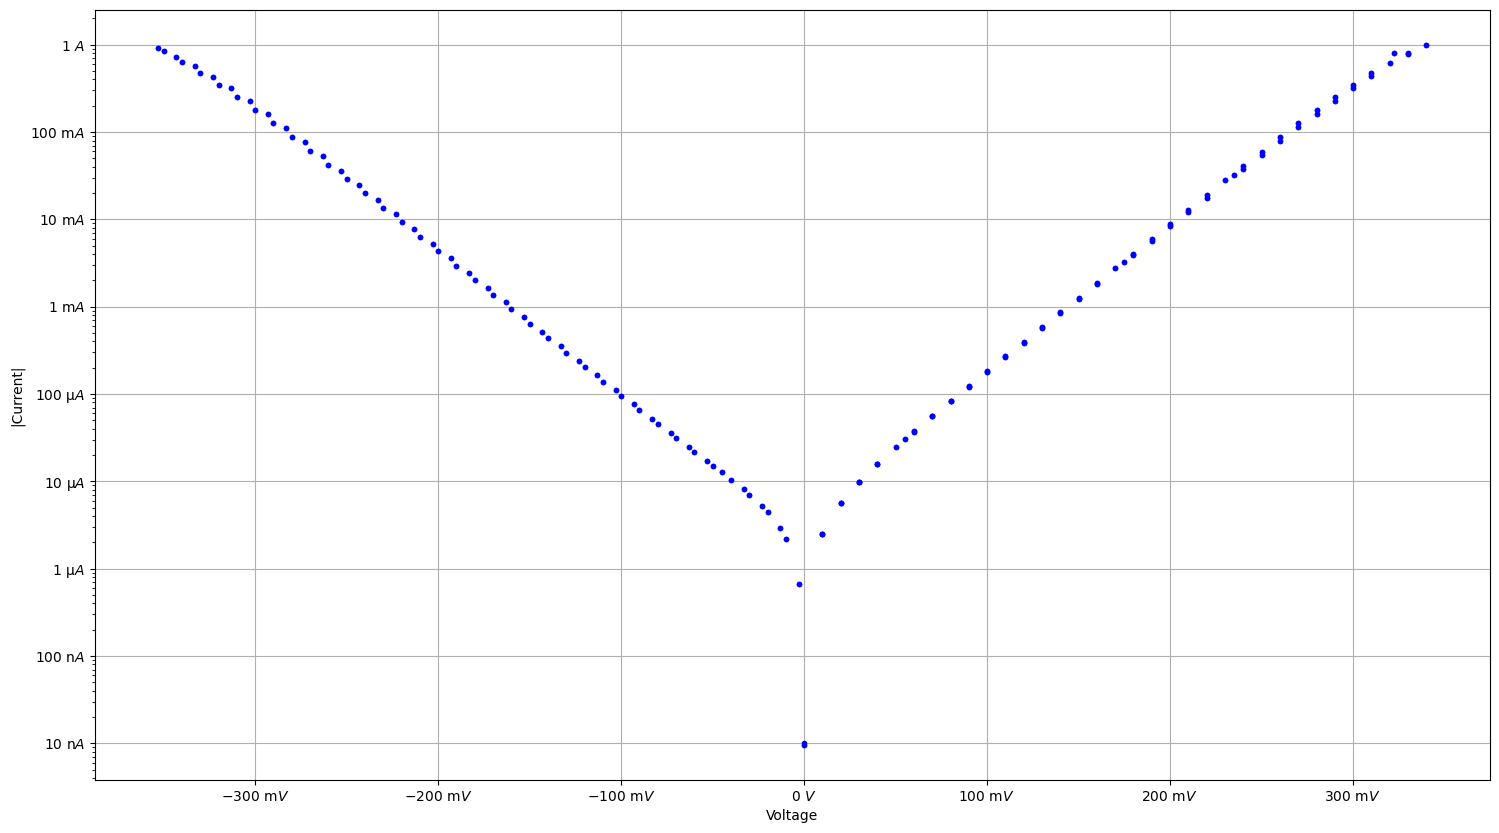

In [10]:
fig, ax1 = plt.subplots()
(line1,) = ax1.semilogy(
    stair_voltage_end_values,
    np.abs(stair_current_end_values),
    color="blue",
    marker="o",
    markersize=3,
    linestyle="None",
)

ax1.xaxis.set_major_formatter(EngFormatter(unit="$V$"))
ax1.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
ax1.set_xlabel("Voltage")
ax1.set_ylabel("|Current|")
ax1.grid()

fig.set_size_inches(18, 10)
plt.show()